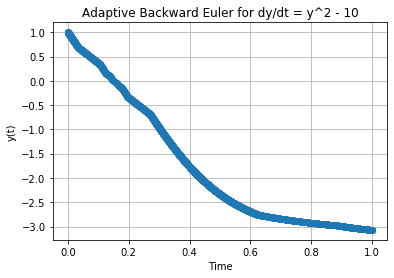

t values:
[0.0000000e+00 3.9062500e-04 7.8125000e-04 ... 9.9921875e-01 1.0000000e+00
 1.0000000e+00]
y values:
[ 1.          0.99648232  0.9929619  ... -3.06974942 -3.0701983
 -3.0701983 ]
Number of steps: 1737


In [2]:
import numpy as np
import matplotlib.pyplot as plt

def f(t, y):
    return y**2 - 10

def fprime(y):
    return 2*y

def backward_euler_step(f, y, t, h, tol=1e-6, max_iter=50):
    y_next = y
    
    for _ in range(max_iter):
        g_val = y_next - y - h * f(t + h, y_next)
        g_prime_val = 1 - h * fprime(y_next)
        
        if abs(g_prime_val) < tol:
            break
        
        y_new = y_next - g_val / g_prime_val
        
        if abs(y_new - y_next) < tol:
            return y_new
        
        y_next = y_new
    
    return y_next

def backward_euler_adaptive(f, y0, t0, tf, h_init, tol=1e-6, max_iter=50):
    t_values = [t0]
    y_values = [y0]
    
    h = h_init
    t = t0
    y = y0
    
    while t < tf:
        if t + h > tf:
            h = tf - t
        
        y_full = backward_euler_step(f, y, t, h, tol, max_iter)
        
        h_half = h / 2
        y_half_1 = backward_euler_step(f, y, t, h_half, tol, max_iter)
        y_half_2 = backward_euler_step(f, y_half_1, t + h_half, h_half, tol, max_iter)
        
        error = abs(y_full - y_half_2)
        
        if error > tol:
            h /= 2
            continue
        elif error < tol / 2:
            h *= 2
        
        t += h
        y = y_half_2
        
        t_values.append(t)
        y_values.append(y)
    
    return np.array(t_values), np.array(y_values)

y0 = 1
t0 = 0
tf = 1
h_init = 0.1

t_values, y_values = backward_euler_adaptive(f, y0, t0, tf, h_init)

plt.plot(t_values, y_values, "o-")
plt.xlabel("Time")
plt.ylabel("y(t)")
plt.title("Adaptive Backward Euler for dy/dt = y^2 - 10")
plt.grid()
plt.show()

print("t values:")
print(t_values)

print("y values:")
print(y_values)

print("Number of steps:", len(t_values) - 1)